In [1]:
import pandas as pd
import matplotlib.pyplot as plt

market = pd.read_csv("../data/market_master.csv")

market["Date"] = pd.to_datetime(market["Date"])
market = market.set_index("Date")

market.head()

,nifty_close,nifty_ret,bank_close,bank_ret,relative_strength,breadth_signal,vix,usd_inr,crude,vix_ret,vix_signal,usd_mom,crude_mom,vol_20,vol_signal,position,position_change,cost,strategy_ret,equity_curve
Date,,,,,,,,,,,,,,,,,,,,
2018-04-11,10417.150391,0.001432,25097.958984,-0.005096,-0.006528,0.000699,14.72,64.925301,66.820000,0.015172,-0.019840,-0.001380,0.019374,0.008697,0.009594,1,0.0,0.0,0.001432,0.990426
2018-04-12,10458.650391,0.003984,25194.806641,0.003859,-0.000125,0.000432,14.56,65.190002,67.070000,-0.010870,-0.003164,0.007651,0.027893,0.008742,0.009326,1,0.0,0.0,0.003984,0.994371
2018-04-13,10480.599609,0.002099,25200.306641,0.000218,-0.001880,0.000251,14.14,65.275703,67.389999,-0.028846,-0.008258,0.005859,0.046754,0.008742,0.009111,1,0.0,0.0,0.002099,0.996458
2018-04-16,10528.349609,0.004556,25320.554688,0.004772,0.000216,0.000974,14.26,65.195602,66.220001,0.008487,-0.008188,0.001384,0.050944,0.008698,0.008912,1,0.0,0.0,0.004556,1.000998
2018-04-17,10548.700195,0.001933,25334.154297,0.000537,-0.001396,0.000411,14.04,65.429298,66.519997,-0.015428,-0.006297,0.004441,0.047394,0.007751,0.008526,1,0.0,0.0,0.001933,1.002933


In [2]:
market.columns

Index(['nifty_close', 'nifty_ret', 'bank_close', 'bank_ret',
       'relative_strength', 'breadth_signal', 'vix', 'usd_inr', 'crude',
       'vix_ret', 'vix_signal', 'usd_mom', 'crude_mom', 'vol_20', 'vol_signal',
       'position', 'position_change', 'cost', 'strategy_ret', 'equity_curve'],
      dtype='object')

In [ ]:
market["vol_20"] = market["nifty_ret"].rolling(20).std()

market["vol_signal"] = market["vol_20"].rolling(5).mean()


In [4]:
market["position"] = (market["breadth_signal"] > 0).astype(int)
market["position_change"] = market["position"].diff().abs()

cost_per_trade = 0.0005   # 5 bps

market["cost"] = market["position_change"] * cost_per_trade

market["strategy_ret"] = market["position"].shift(1) * market["nifty_ret"] - market["cost"]

market["equity_curve"] = (1 + market["strategy_ret"]).cumprod()

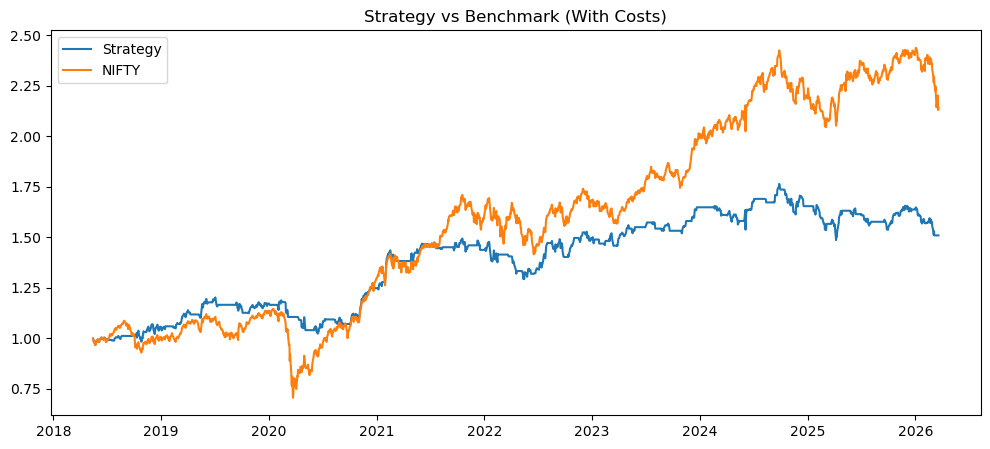

In [5]:
plt.figure(figsize=(12,5))
plt.plot(market.index, market["equity_curve"], label="Strategy")
plt.plot(market.index, (1 + market["nifty_ret"]).cumprod(), label="NIFTY")
plt.legend()
plt.title("Strategy vs Benchmark (With Costs)")
plt.show()

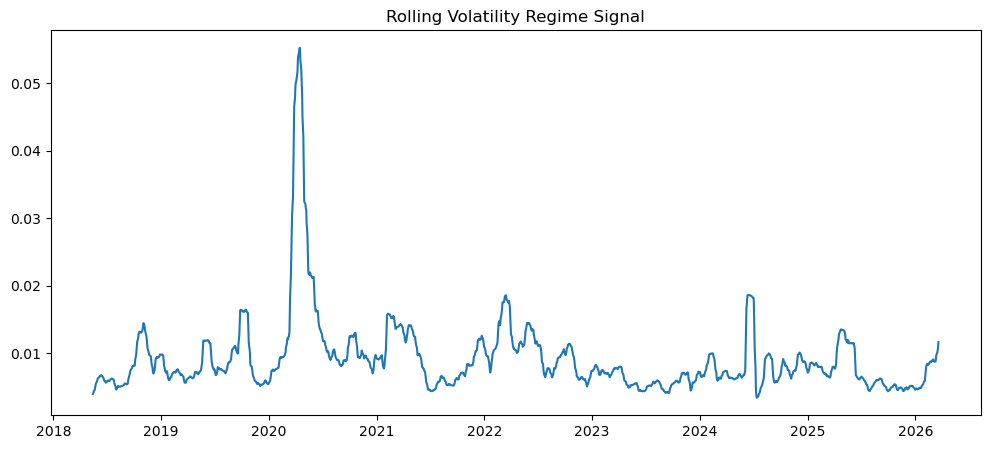

In [6]:
plt.figure(figsize=(12,5))
plt.plot(market.index, market["vol_signal"])
plt.title("Rolling Volatility Regime Signal")
plt.show()

In [7]:
market = market.dropna()

In [8]:
market.to_csv("../data/market_master.csv")